
# Crossfit pilot comprehensive diagnostics

This notebook analyzes the repeated symmetric cross-fit pilot results saved in:

`C:/Users/yangy/26 spring/with reference/crossfit`

Project rule used here:

- target is **pointwise final deployed coverage near 0.95**
- focus is on the points that remain **undercovered** under the final selected deployed rule
- overcoverage is **not** treated as the main issue here

The notebook separates three objects:

1. **Estimated coverage**: cross-fit pseudo-truth coverage used to choose `alpha_star(x)`
2. **Calibration true-hit coverage**: what happens inside the repeated cross-fit calibration bank if we test against the known simulation truth `f0`
3. **Final deployed coverage**: full-data deployed family tested against `f0`

This lets us decompose mismatch into:

- **pseudo-target bias** = calibration true-hit - estimated pseudo-hit
- **deploy transfer gap** = final deployed coverage - calibration true-hit
- **total gap** = final deployed coverage - estimated coverage

Compared with the earlier family-fix runs, this notebook also adds **direction-level diagnostics** for the repeated symmetric cross-fit surfaces.


In [1]:

from pathlib import Path
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 140
plt.rcParams["savefig.dpi"] = 160

RESULTS_DIR = Path(r"C:\Users\yangy\26 spring\with reference\crossfit")
OUTPUT_DIR = RESULTS_DIR / "comprehensive_diagnostics"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RESULTS_DIR, OUTPUT_DIR


(WindowsPath('C:/Users/yangy/26 spring/with reference/crossfit'),
 WindowsPath('C:/Users/yangy/26 spring/with reference/crossfit/comprehensive_diagnostics'))

## 1. Load files and validate grids / shapes

In [2]:

DEPLOY_SELECTED_PATTERN = "deploy_final_rep*_J*.csv"
DEPLOY_BANK_PATTERN = "deploy_full_by_alpha_rep*_A*_J*.npz"
COVERAGE_PATTERN = "pointwise_coverage_rep*_A*_B*_S*.csv"
ALPHA_STAR_PATTERN = "alpha_star_curve_rep*.csv"
DIRECTIONAL_COVERAGE_PATTERN = "directional_coverage_rep*_S*_A*_J*.npy"
DIRECTIONAL_PSEUDO_PATTERN = "directional_pseudo_truth_rep*_S*_A*_J*.npy"
COVERAGE_CROSSFIT_PATTERN = "coverage_crossfit_rep*_A*_S*_J*.npy"
CALIB_BANK_PATTERN = "calib_crossfit_interval_bank_rep*_S*_A*_B*_J*.npz"
META_PATTERN = "meta_rep*.json"

rep_regex = re.compile(r"rep(\d+)")

def parse_rep_id(path: Path) -> int:
    m = rep_regex.search(path.stem)
    if m is None:
        raise ValueError(f"Could not parse rep id from {path.name}")
    return int(m.group(1))


def load_optional_json(path: Path):
    if path is None or not path.exists():
        return None
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


deploy_selected_files = sorted(RESULTS_DIR.glob(DEPLOY_SELECTED_PATTERN), key=parse_rep_id)
deploy_bank_files = {parse_rep_id(p): p for p in RESULTS_DIR.glob(DEPLOY_BANK_PATTERN)}
coverage_files = {parse_rep_id(p): p for p in RESULTS_DIR.glob(COVERAGE_PATTERN)}
alpha_star_files = {parse_rep_id(p): p for p in RESULTS_DIR.glob(ALPHA_STAR_PATTERN)}
directional_cov_files = {parse_rep_id(p): p for p in RESULTS_DIR.glob(DIRECTIONAL_COVERAGE_PATTERN)}
directional_pseudo_files = {parse_rep_id(p): p for p in RESULTS_DIR.glob(DIRECTIONAL_PSEUDO_PATTERN)}
coverage_crossfit_files = {parse_rep_id(p): p for p in RESULTS_DIR.glob(COVERAGE_CROSSFIT_PATTERN)}
calib_bank_files = {parse_rep_id(p): p for p in RESULTS_DIR.glob(CALIB_BANK_PATTERN)}
meta_files = {parse_rep_id(p): p for p in RESULTS_DIR.glob(META_PATTERN)}

print(f"Found {len(deploy_selected_files)} selected deploy files")
print(f"Found {len(deploy_bank_files)} deploy alpha-bank files")
print(f"Found {len(coverage_files)} pointwise coverage files")
print(f"Found {len(alpha_star_files)} alpha-star files")
print(f"Found {len(directional_cov_files)} directional coverage files")
print(f"Found {len(directional_pseudo_files)} directional pseudo-truth files")
print(f"Found {len(coverage_crossfit_files)} coverage_crossfit files")
print(f"Found {len(calib_bank_files)} calibration-bank files")
print(f"Found {len(meta_files)} meta files")

if len(deploy_selected_files) == 0:
    raise FileNotFoundError(f"No files matching {DEPLOY_SELECTED_PATTERN} were found in {RESULTS_DIR}")

required = {
    "deploy_bank": deploy_bank_files,
    "coverage": coverage_files,
    "alpha_star": alpha_star_files,
    "directional_coverage": directional_cov_files,
    "directional_pseudo": directional_pseudo_files,
    "coverage_crossfit": coverage_crossfit_files,
    "calib_bank": calib_bank_files,
    "meta": meta_files,
}
for name, mapping in required.items():
    missing = [parse_rep_id(p) for p in deploy_selected_files if parse_rep_id(p) not in mapping]
    if missing:
        raise FileNotFoundError(f"Missing {name} files for rep ids: {missing[:10]}")


Found 20 selected deploy files
Found 20 deploy alpha-bank files
Found 20 pointwise coverage files
Found 20 alpha-star files
Found 20 directional coverage files
Found 20 directional pseudo-truth files
Found 20 coverage_crossfit files
Found 20 calibration-bank files
Found 20 meta files


In [3]:

records = []
x_ref = None
true_f_ref = None
ci_level = None
z_ci = None
alpha_vals_ref = None
B_ref = None
S_ref = None
num_splits_ref = None

for deploy_path in deploy_selected_files:
    rep_id = parse_rep_id(deploy_path)
    deploy_df = pd.read_csv(deploy_path).sort_values("x").reset_index(drop=True)

    if x_ref is None:
        x_ref = deploy_df["x"].to_numpy(dtype=float)
        true_f_ref = deploy_df["true_f"].to_numpy(dtype=float)
    else:
        if not np.allclose(x_ref, deploy_df["x"].to_numpy(dtype=float)):
            raise ValueError(f"x-grid mismatch in selected deploy file for rep {rep_id}")
        if not np.allclose(true_f_ref, deploy_df["true_f"].to_numpy(dtype=float)):
            raise ValueError(f"true_f mismatch in selected deploy file for rep {rep_id}")

    meta = load_optional_json(meta_files.get(rep_id))
    if meta is not None and ci_level is None:
        ci_level = float(meta.get("ci_level", np.nan))
        z_ci = float(meta.get("z_ci", np.nan))
        num_splits_ref = int(meta.get("num_splits", -1))

    alpha_df = pd.read_csv(alpha_star_files[rep_id]).sort_values("x").reset_index(drop=True)
    if not np.allclose(x_ref, alpha_df["x"].to_numpy(dtype=float)):
        raise ValueError(f"x-grid mismatch in alpha_star file for rep {rep_id}")

    cov_df = pd.read_csv(coverage_files[rep_id]).sort_values("x").reset_index(drop=True)
    if not np.allclose(x_ref, cov_df["x"].to_numpy(dtype=float)):
        raise ValueError(f"x-grid mismatch in pointwise coverage file for rep {rep_id}")
    alpha_cols = [c for c in cov_df.columns if c.startswith("alpha_")]
    alpha_vals = np.array([float(c.split("_", 1)[1]) for c in alpha_cols], dtype=float)
    order = np.argsort(alpha_vals)
    alpha_vals = alpha_vals[order]
    alpha_cols = [alpha_cols[i] for i in order]
    cov_df = cov_df[["x"] + alpha_cols].copy()

    deploy_bank = np.load(deploy_bank_files[rep_id])
    bank_x = np.array(deploy_bank["x"], dtype=float)
    bank_alphas = np.array(deploy_bank["alphas"], dtype=float)
    mu_bank = np.array(deploy_bank["mu"], dtype=float)
    std_bank = np.array(deploy_bank["std"], dtype=float)
    lower_bank = np.array(deploy_bank["lower"], dtype=float)
    upper_bank = np.array(deploy_bank["upper"], dtype=float)

    calib_bank = np.load(calib_bank_files[rep_id])
    calib_x = np.array(calib_bank["x"], dtype=float)
    calib_alphas = np.array(calib_bank["alphas"], dtype=float)
    calib_mu = np.array(calib_bank["mu"], dtype=float)
    calib_std = np.array(calib_bank["std"], dtype=float)
    calib_lower = np.array(calib_bank["lower"], dtype=float)
    calib_upper = np.array(calib_bank["upper"], dtype=float)
    calib_pseudo = np.array(calib_bank["pseudo_truth"], dtype=float)
    calib_ind = np.array(calib_bank["indicators"], dtype=float)

    directional_cov = np.load(directional_cov_files[rep_id])
    directional_pseudo = np.load(directional_pseudo_files[rep_id])
    coverage_crossfit = np.load(coverage_crossfit_files[rep_id])

    if not np.allclose(x_ref, bank_x):
        raise ValueError(f"x-grid mismatch in deploy alpha bank for rep {rep_id}")
    if not np.allclose(x_ref, calib_x):
        raise ValueError(f"x-grid mismatch in calib bank for rep {rep_id}")

    if alpha_vals_ref is None:
        alpha_vals_ref = bank_alphas.copy()
        B_ref = int(calib_mu.shape[2])
        S_ref = int(calib_mu.shape[0])
    else:
        if len(alpha_vals_ref) != len(bank_alphas) or not np.allclose(alpha_vals_ref, bank_alphas):
            raise ValueError(f"alpha grid mismatch in deploy bank for rep {rep_id}")
        if len(alpha_vals_ref) != len(calib_alphas) or not np.allclose(alpha_vals_ref, calib_alphas):
            raise ValueError(f"alpha grid mismatch in calib bank for rep {rep_id}")
        if len(alpha_vals_ref) != len(alpha_vals) or not np.allclose(alpha_vals_ref, alpha_vals):
            raise ValueError(f"alpha grid mismatch in pointwise coverage csv for rep {rep_id}")
        if S_ref != int(calib_mu.shape[0]) or B_ref != int(calib_mu.shape[2]):
            raise ValueError(f"S/B mismatch in calib bank for rep {rep_id}")

    if directional_cov.shape != calib_pseudo.shape:
        raise ValueError(f"directional coverage / pseudo shape mismatch for rep {rep_id}")
    if directional_pseudo.shape != calib_pseudo.shape:
        raise ValueError(f"directional pseudo shape mismatch for rep {rep_id}")
    if coverage_crossfit.shape != (len(alpha_vals_ref), len(x_ref)):
        raise ValueError(f"coverage_crossfit shape mismatch for rep {rep_id}")
    if calib_mu.shape != calib_std.shape or calib_mu.shape != calib_lower.shape or calib_mu.shape != calib_upper.shape:
        raise ValueError(f"calibration interval bank shape mismatch for rep {rep_id}")
    if calib_mu.shape != (S_ref, len(alpha_vals_ref), B_ref, len(x_ref)):
        raise ValueError(f"Unexpected calib bank shape for rep {rep_id}: {calib_mu.shape}")

    records.append({
        "rep_id": rep_id,
        "deploy_df": deploy_df,
        "alpha_df": alpha_df,
        "coverage_df": cov_df,
        "meta": meta,
        "alphas": bank_alphas,
        "mu_bank": mu_bank,
        "std_bank": std_bank,
        "lower_bank": lower_bank,
        "upper_bank": upper_bank,
        "calib_mu": calib_mu,
        "calib_std": calib_std,
        "calib_lower": calib_lower,
        "calib_upper": calib_upper,
        "calib_pseudo": calib_pseudo,
        "calib_ind": calib_ind,
        "directional_cov": directional_cov,
        "directional_pseudo": directional_pseudo,
        "coverage_crossfit": coverage_crossfit,
    })

print(f"Loaded {len(records)} replications")
print(f"Nominal CI level from meta: {ci_level}")
print(f"z_ci from meta: {z_ci}")
print(f"Alpha grid: {alpha_vals_ref}")
print(f"Number of directions S: {S_ref}")
print(f"Bootstrap count B: {B_ref}")
print(f"num_splits from meta: {num_splits_ref}")


Loaded 20 replications
Nominal CI level from meta: 0.95
z_ci from meta: 1.959963984540054
Alpha grid: [0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]
Number of directions S: 10
Bootstrap count B: 50
num_splits from meta: 5


## 2. Build tensors and core summaries

In [4]:

rep_ids = np.array([r["rep_id"] for r in records], dtype=int)
R = len(records)
J = len(x_ref)
A = len(alpha_vals_ref)
S = int(S_ref)
B = int(B_ref)
nominal = float(ci_level) if ci_level is not None else 0.95
eps = 1e-12

selected_hit_mat = np.vstack([r["deploy_df"]["hit"].to_numpy(dtype=float) for r in records])
selected_alpha_mat = np.vstack([r["deploy_df"]["alpha_star"].to_numpy(dtype=float) for r in records])

est_cov_all_tensor = np.stack([r["coverage_crossfit"].T for r in records], axis=0)  # (R, J, A)
directional_cov_tensor = np.stack([np.transpose(r["directional_cov"], (2, 1, 0)) for r in records], axis=0)  # (R, J, A, S)

calib_pseudo_cov_all_tensor = np.zeros((R, J, A), dtype=float)
calib_true_cov_all_tensor = np.zeros((R, J, A), dtype=float)
calib_pseudo_cov_dir_tensor = np.zeros((R, J, A, S), dtype=float)
calib_true_cov_dir_tensor = np.zeros((R, J, A, S), dtype=float)
calib_pseudo_z_tensor = np.zeros((R, J, A, S, B), dtype=float)
calib_true_z_tensor = np.zeros((R, J, A, S, B), dtype=float)

actual_hit_all_tensor = np.zeros((R, J, A), dtype=float)
mu_all_tensor = np.zeros((R, J, A), dtype=float)
std_all_tensor = np.zeros((R, J, A), dtype=float)
lower_all_tensor = np.zeros((R, J, A), dtype=float)
upper_all_tensor = np.zeros((R, J, A), dtype=float)

for r_idx, rec in enumerate(records):
    true_f = rec["deploy_df"]["true_f"].to_numpy(dtype=float)

    actual_hit_all_tensor[r_idx] = ((true_f[None, :] >= rec["lower_bank"]) & (true_f[None, :] <= rec["upper_bank"])).T.astype(float)
    mu_all_tensor[r_idx] = rec["mu_bank"].T
    std_all_tensor[r_idx] = rec["std_bank"].T
    lower_all_tensor[r_idx] = rec["lower_bank"].T
    upper_all_tensor[r_idx] = rec["upper_bank"].T

    pseudo = rec["calib_pseudo"]
    lower = rec["calib_lower"]
    upper = rec["calib_upper"]
    mu = rec["calib_mu"]
    std = rec["calib_std"]
    ind = rec["calib_ind"]

    calib_pseudo_cov_dir = ind.mean(axis=2)  # (S, A, J)
    true_hit_boot = ((true_f[None, None, None, :] >= lower) & (true_f[None, None, None, :] <= upper)).astype(float)  # (S, A, B, J)
    calib_true_cov_dir = true_hit_boot.mean(axis=2)

    calib_pseudo_cov_dir_tensor[r_idx] = np.transpose(calib_pseudo_cov_dir, (2, 1, 0))
    calib_true_cov_dir_tensor[r_idx] = np.transpose(calib_true_cov_dir, (2, 1, 0))
    calib_pseudo_cov_all_tensor[r_idx] = calib_pseudo_cov_dir_tensor[r_idx].mean(axis=2)
    calib_true_cov_all_tensor[r_idx] = calib_true_cov_dir_tensor[r_idx].mean(axis=2)

    pseudo_z = (pseudo[:, :, None, :] - mu) / np.maximum(std, eps)
    true_z = (true_f[None, None, None, :] - mu) / np.maximum(std, eps)
    calib_pseudo_z_tensor[r_idx] = np.transpose(pseudo_z, (3, 1, 0, 2))
    calib_true_z_tensor[r_idx] = np.transpose(true_z, (3, 1, 0, 2))

pointwise_selected_actual = selected_hit_mat.mean(axis=0)
actual_cov_all_mean = actual_hit_all_tensor.mean(axis=0)
est_cov_all_mean = est_cov_all_tensor.mean(axis=0)
calib_pseudo_cov_all_mean = calib_pseudo_cov_all_tensor.mean(axis=0)
calib_true_cov_all_mean = calib_true_cov_all_tensor.mean(axis=0)

under_mask = pointwise_selected_actual < nominal
under_idx = np.flatnonzero(under_mask)
U = len(under_idx)

summary = {
    "R": int(R),
    "J": int(J),
    "A": int(A),
    "S": int(S),
    "B": int(B),
    "rep_id_min": int(rep_ids.min()),
    "rep_id_max": int(rep_ids.max()),
    "nominal": float(nominal),
    "undercovered_selected_points": int(U),
}
summary


{'R': 20,
 'J': 50,
 'A': 10,
 'S': 10,
 'B': 50,
 'rep_id_min': 0,
 'rep_id_max': 19,
 'nominal': 0.95,
 'undercovered_selected_points': 5}

## 3. Reconstruction / consistency audit

In [5]:

recon_rows = []
for rec in records:
    deploy_df = rec["deploy_df"]
    alpha_vec = deploy_df["alpha_star"].to_numpy(dtype=float)
    alpha_idx = np.array([int(np.argmin(np.abs(alpha_vals_ref - a))) for a in alpha_vec], dtype=int)

    mu_bank = rec["mu_bank"]
    std_bank = rec["std_bank"]
    lower_bank = rec["lower_bank"]
    upper_bank = rec["upper_bank"]
    selected_mu = mu_bank[alpha_idx, np.arange(J)]
    selected_std = std_bank[alpha_idx, np.arange(J)]
    selected_lower = lower_bank[alpha_idx, np.arange(J)]
    selected_upper = upper_bank[alpha_idx, np.arange(J)]

    cov_mat = rec["coverage_df"].iloc[:, 1:].to_numpy(dtype=float)
    selected_est_csv = cov_mat[np.arange(J), alpha_idx]
    selected_est_crossfit = rec["coverage_crossfit"][alpha_idx, np.arange(J)]

    calib_ind = rec["calib_ind"]
    chosen = calib_ind[np.arange(S)[:, None], alpha_idx[None, :], :, np.arange(J)[None, :]]
    selected_est_from_bank = chosen.mean(axis=(0, 2))

    recon_rows.append({
        "rep_id": int(rec["rep_id"]),
        "max_abs_alpha_diff_deploy_vs_curve": float(np.max(np.abs(alpha_vec - rec["alpha_df"]["alpha_star"].to_numpy(dtype=float)))),
        "max_abs_mu_diff_reconstructed_vs_saved": float(np.max(np.abs(selected_mu - deploy_df["mu"].to_numpy(dtype=float)))),
        "max_abs_std_diff_reconstructed_vs_saved": float(np.max(np.abs(selected_std - deploy_df["std"].to_numpy(dtype=float)))),
        "max_abs_lower_diff_reconstructed_vs_saved": float(np.max(np.abs(selected_lower - deploy_df["lower"].to_numpy(dtype=float)))),
        "max_abs_upper_diff_reconstructed_vs_saved": float(np.max(np.abs(selected_upper - deploy_df["upper"].to_numpy(dtype=float)))),
        "max_abs_selected_est_diff_csv_vs_crossfit": float(np.max(np.abs(selected_est_csv - selected_est_crossfit))),
        "max_abs_selected_est_diff_crossfit_vs_calib_bank": float(np.max(np.abs(selected_est_crossfit - selected_est_from_bank))),
        "hit_match_all_points": bool(np.array_equal(((true_f_ref >= selected_lower) & (true_f_ref <= selected_upper)).astype(np.int8), deploy_df["hit"].to_numpy(dtype=np.int8))),
    })

recon_df = pd.DataFrame(recon_rows)
recon_df.to_csv(OUTPUT_DIR / "00_reconstruction_consistency_per_rep.csv", index=False)

recon_summary = {
    "recon_all_alpha_curve_match": bool(np.allclose(recon_df["max_abs_alpha_diff_deploy_vs_curve"], 0.0)),
    "recon_all_mu_match": bool(np.allclose(recon_df["max_abs_mu_diff_reconstructed_vs_saved"], 0.0)),
    "recon_all_std_match": bool(np.allclose(recon_df["max_abs_std_diff_reconstructed_vs_saved"], 0.0)),
    "recon_all_lower_match": bool(np.allclose(recon_df["max_abs_lower_diff_reconstructed_vs_saved"], 0.0)),
    "recon_all_upper_match": bool(np.allclose(recon_df["max_abs_upper_diff_reconstructed_vs_saved"], 0.0)),
    "recon_all_est_match_csv_vs_crossfit": bool(np.allclose(recon_df["max_abs_selected_est_diff_csv_vs_crossfit"], 0.0)),
    "recon_all_est_match_crossfit_vs_calib_bank": bool(np.allclose(recon_df["max_abs_selected_est_diff_crossfit_vs_calib_bank"], 0.0)),
    "recon_all_hit_match": bool(recon_df["hit_match_all_points"].all()),
}

pd.DataFrame([{**summary, **recon_summary}]).to_csv(OUTPUT_DIR / "00_overall_summary.csv", index=False)
recon_summary


{'recon_all_alpha_curve_match': True,
 'recon_all_mu_match': True,
 'recon_all_std_match': True,
 'recon_all_lower_match': True,
 'recon_all_upper_match': True,
 'recon_all_est_match_csv_vs_crossfit': True,
 'recon_all_est_match_crossfit_vs_calib_bank': True,
 'recon_all_hit_match': True}

## 4. Selected-chain pointwise summary


For the selected `alpha*(x)`, compare:

- selected estimated coverage
- selected calibration pseudo-hit share
- selected calibration true-hit share
- selected final deployed coverage

This is the most direct decomposition of the logic chain.


In [6]:

selected_est_cov_mat = np.zeros((R, J), dtype=float)
selected_calib_pseudo_cov_mat = np.zeros((R, J), dtype=float)
selected_calib_true_cov_mat = np.zeros((R, J), dtype=float)
selected_calib_pseudo_z_meanabs_mat = np.zeros((R, J), dtype=float)
selected_calib_true_z_meanabs_mat = np.zeros((R, J), dtype=float)
selected_calib_pseudo_z_signed_mat = np.zeros((R, J), dtype=float)
selected_calib_true_z_signed_mat = np.zeros((R, J), dtype=float)
selected_deploy_pseudo_z_mat = np.zeros((R, J), dtype=float)
selected_deploy_true_z_mat = np.zeros((R, J), dtype=float)
selected_deploy_pseudo_hit_mat = np.zeros((R, J), dtype=float)
selected_directional_est_sd_mat = np.zeros((R, J), dtype=float)
selected_directional_true_sd_mat = np.zeros((R, J), dtype=float)

for r_idx, rec in enumerate(records):
    alpha_vec = rec["deploy_df"]["alpha_star"].to_numpy(dtype=float)
    alpha_idx = np.array([int(np.argmin(np.abs(alpha_vals_ref - a))) for a in alpha_vec], dtype=int)

    selected_est_cov_mat[r_idx] = rec["coverage_crossfit"][alpha_idx, np.arange(J)]

    calib_ind = rec["calib_ind"]
    calib_true_hit = ((true_f_ref[None, None, None, :] >= rec["calib_lower"]) & (true_f_ref[None, None, None, :] <= rec["calib_upper"])).astype(float)
    selected_calib_pseudo_cov_mat[r_idx] = calib_ind[np.arange(S)[:, None], alpha_idx[None, :], :, np.arange(J)[None, :]].mean(axis=(0, 2))
    selected_calib_true_cov_mat[r_idx] = calib_true_hit[np.arange(S)[:, None], alpha_idx[None, :], :, np.arange(J)[None, :]].mean(axis=(0, 2))

    pseudo_dir = calib_ind.mean(axis=2)
    true_dir = calib_true_hit.mean(axis=2)
    selected_directional_est_sd_mat[r_idx] = pseudo_dir[np.arange(S)[:, None], alpha_idx[None, :], np.arange(J)[None, :]].std(axis=0, ddof=1)
    selected_directional_true_sd_mat[r_idx] = true_dir[np.arange(S)[:, None], alpha_idx[None, :], np.arange(J)[None, :]].std(axis=0, ddof=1)

    pseudo = rec["calib_pseudo"]
    mu = rec["calib_mu"]
    std = rec["calib_std"]
    pseudo_sel = pseudo[np.arange(S)[:, None], alpha_idx[None, :], np.arange(J)[None, :]]
    mu_sel = mu[np.arange(S)[:, None], alpha_idx[None, :], :, np.arange(J)[None, :]]
    std_sel = std[np.arange(S)[:, None], alpha_idx[None, :], :, np.arange(J)[None, :]]
    z_pseudo_sel = (pseudo_sel[:, :, None] - mu_sel) / np.maximum(std_sel, eps)
    z_true_sel = (true_f_ref[None, :, None] - mu_sel) / np.maximum(std_sel, eps)
    selected_calib_pseudo_z_meanabs_mat[r_idx] = np.mean(np.abs(z_pseudo_sel), axis=(0, 2))
    selected_calib_true_z_meanabs_mat[r_idx] = np.mean(np.abs(z_true_sel), axis=(0, 2))
    selected_calib_pseudo_z_signed_mat[r_idx] = np.mean(z_pseudo_sel, axis=(0, 2))
    selected_calib_true_z_signed_mat[r_idx] = np.mean(z_true_sel, axis=(0, 2))

    mu_bank = rec["mu_bank"]
    std_bank = rec["std_bank"]
    lower_bank = rec["lower_bank"]
    upper_bank = rec["upper_bank"]
    pseudo_full = rec["calib_pseudo"].mean(axis=0)
    sel_mu = mu_bank[alpha_idx, np.arange(J)]
    sel_std = std_bank[alpha_idx, np.arange(J)]
    sel_lower = lower_bank[alpha_idx, np.arange(J)]
    sel_upper = upper_bank[alpha_idx, np.arange(J)]
    sel_pseudo = pseudo_full[alpha_idx, np.arange(J)]
    selected_deploy_pseudo_z_mat[r_idx] = (sel_pseudo - sel_mu) / np.maximum(sel_std, eps)
    selected_deploy_true_z_mat[r_idx] = (true_f_ref - sel_mu) / np.maximum(sel_std, eps)
    selected_deploy_pseudo_hit_mat[r_idx] = ((sel_pseudo >= sel_lower) & (sel_pseudo <= sel_upper)).astype(float)

pointwise_selected_df = pd.DataFrame({
    "x": x_ref,
    "true_f": true_f_ref,
    "selected_estimated_coverage": selected_est_cov_mat.mean(axis=0),
    "selected_calib_pseudo_hit_share": selected_calib_pseudo_cov_mat.mean(axis=0),
    "selected_calib_true_hit_share": selected_calib_true_cov_mat.mean(axis=0),
    "selected_actual_deploy_coverage": pointwise_selected_actual,
    "selected_calib_true_minus_estimated": selected_calib_true_cov_mat.mean(axis=0) - selected_est_cov_mat.mean(axis=0),
    "selected_deploy_minus_calib_true": pointwise_selected_actual - selected_calib_true_cov_mat.mean(axis=0),
    "selected_deploy_minus_estimated": pointwise_selected_actual - selected_est_cov_mat.mean(axis=0),
    "selected_directional_estimated_sd": selected_directional_est_sd_mat.mean(axis=0),
    "selected_directional_calib_true_sd": selected_directional_true_sd_mat.mean(axis=0),
    "alpha_star_mean": selected_alpha_mat.mean(axis=0),
    "alpha_star_sd": selected_alpha_mat.std(axis=0, ddof=1) if R > 1 else np.zeros(J),
    "nominal": nominal,
    "gap_to_nominal": nominal - pointwise_selected_actual,
})
pointwise_selected_df.to_csv(OUTPUT_DIR / "01_pointwise_selected_chain_summary.csv", index=False)

undercovered_selected_df = pointwise_selected_df.loc[under_mask].copy()
undercovered_selected_df = undercovered_selected_df.sort_values(["gap_to_nominal", "x"], ascending=[False, True]).reset_index(drop=True)
undercovered_selected_df.to_csv(OUTPUT_DIR / "02_undercovered_selected_chain_summary.csv", index=False)
undercovered_selected_df


,x,true_f,selected_estimated_coverage,selected_calib_pseudo_hit_share,selected_calib_true_hit_share,selected_actual_deploy_coverage,selected_calib_true_minus_estimated,selected_deploy_minus_calib_true,selected_deploy_minus_estimated,selected_directional_estimated_sd,selected_directional_calib_true_sd,alpha_star_mean,alpha_star_sd,nominal,gap_to_nominal
0,-2.193878,-0.460571,0.9590,0.9590,0.9238,0.9,-0.0352,-0.0238,-0.0590,0.053850,0.057447,0.580,0.228496,0.95,0.05
1,-1.275510,-1.374411,0.9862,0.9862,0.9814,0.9,-0.0048,-0.0814,-0.0862,0.028179,0.020663,0.990,0.044721,0.95,0.05
2,-0.969388,-0.295281,0.9770,0.9770,0.9932,0.9,0.0162,-0.0932,-0.0770,0.040268,0.011027,0.985,0.048936,0.95,0.05
3,-0.867347,0.311308,0.9754,0.9754,0.9836,0.9,0.0082,-0.0836,-0.0754,0.046240,0.019812,0.970,0.092338,0.95,0.05
4,1.173469,0.422048,0.9684,0.9684,0.9861,0.9,0.0177,-0.0861,-0.0684,0.045728,0.018914,0.915,0.172520,0.95,0.05


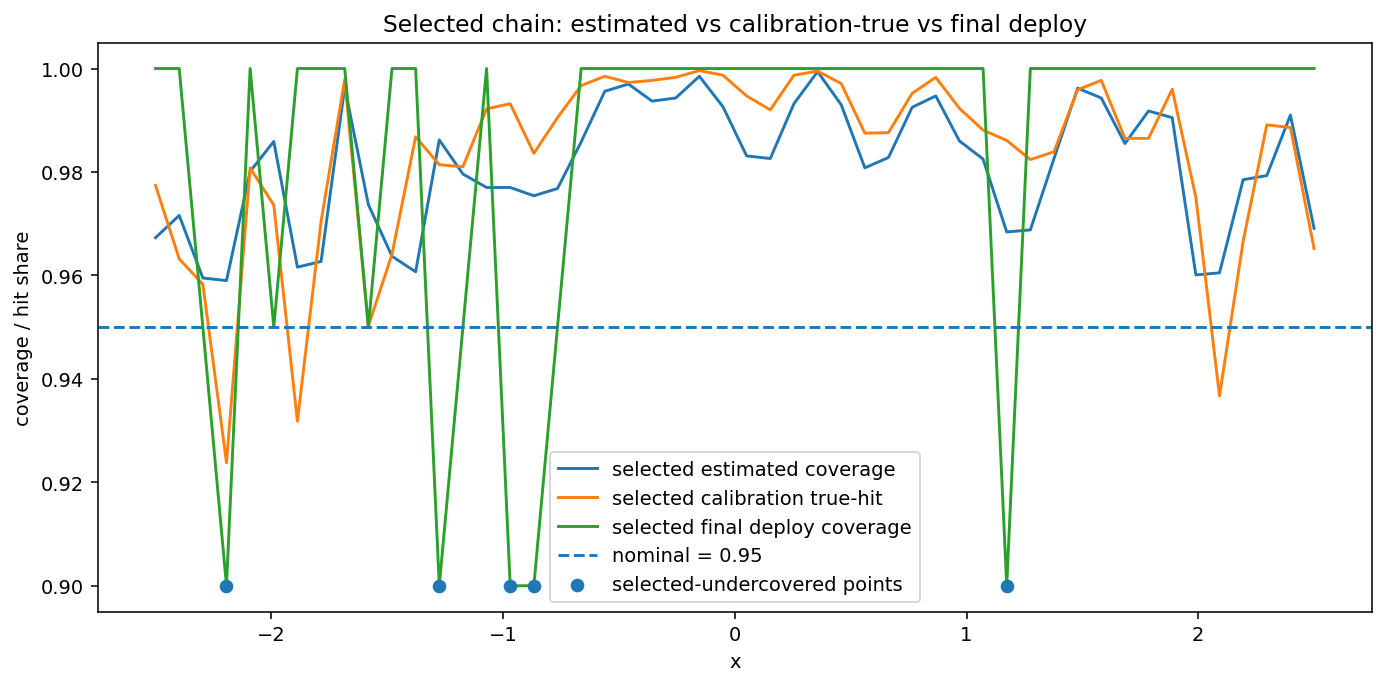

In [7]:

plt.figure(figsize=(10, 5.0))
plt.plot(x_ref, pointwise_selected_df["selected_estimated_coverage"], label="selected estimated coverage")
plt.plot(x_ref, pointwise_selected_df["selected_calib_true_hit_share"], label="selected calibration true-hit")
plt.plot(x_ref, pointwise_selected_df["selected_actual_deploy_coverage"], label="selected final deploy coverage")
plt.axhline(nominal, linestyle="--", label=f"nominal = {nominal:.2f}")
if U > 0:
    plt.scatter(x_ref[under_idx], pointwise_selected_df.loc[under_mask, "selected_actual_deploy_coverage"], label="selected-undercovered points", zorder=3)
plt.xlabel("x")
plt.ylabel("coverage / hit share")
plt.title("Selected chain: estimated vs calibration-true vs final deploy")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "01_selected_chain_three_way.png", bbox_inches="tight")
plt.show()


## 5. Exact calibration-bank center-offset audit


This is the exact version of the pseudo-truth / center audit inside the saved repeated symmetric cross-fit calibration bank.
For the selected alpha:

- compare pseudo-truth hit share vs true-f hit share inside the calibration bank
- compare mean absolute standardized offsets from the calibration interval center
- compare the same quantities under the final deployed interval


In [8]:

selected_center_offset_df = pd.DataFrame({
    "x": x_ref,
    "true_f": true_f_ref,
    "selected_calib_pseudo_hit_share": selected_calib_pseudo_cov_mat.mean(axis=0),
    "selected_calib_true_hit_share": selected_calib_true_cov_mat.mean(axis=0),
    "selected_calib_pseudo_minus_true_hit": selected_calib_pseudo_cov_mat.mean(axis=0) - selected_calib_true_cov_mat.mean(axis=0),
    "mean_abs_selected_calib_pseudo_z": selected_calib_pseudo_z_meanabs_mat.mean(axis=0),
    "mean_abs_selected_calib_true_z": selected_calib_true_z_meanabs_mat.mean(axis=0),
    "mean_abs_selected_calib_true_minus_pseudo_z": selected_calib_true_z_meanabs_mat.mean(axis=0) - selected_calib_pseudo_z_meanabs_mat.mean(axis=0),
    "mean_signed_selected_calib_pseudo_z": selected_calib_pseudo_z_signed_mat.mean(axis=0),
    "mean_signed_selected_calib_true_z": selected_calib_true_z_signed_mat.mean(axis=0),
    "selected_deploy_pseudo_hit_share": selected_deploy_pseudo_hit_mat.mean(axis=0),
    "selected_actual_deploy_coverage": pointwise_selected_actual,
    "selected_deploy_pseudo_minus_true_hit": selected_deploy_pseudo_hit_mat.mean(axis=0) - pointwise_selected_actual,
    "mean_abs_selected_deploy_pseudo_z": np.mean(np.abs(selected_deploy_pseudo_z_mat), axis=0),
    "mean_abs_selected_deploy_true_z": np.mean(np.abs(selected_deploy_true_z_mat), axis=0),
    "mean_abs_selected_deploy_true_minus_pseudo_z": np.mean(np.abs(selected_deploy_true_z_mat), axis=0) - np.mean(np.abs(selected_deploy_pseudo_z_mat), axis=0),
})
selected_center_offset_df.to_csv(OUTPUT_DIR / "03_selected_center_offset_summary.csv", index=False)

undercovered_center_offset_df = selected_center_offset_df.loc[under_mask].copy()
undercovered_center_offset_df = undercovered_center_offset_df.sort_values(["selected_actual_deploy_coverage", "x"], ascending=[True, True]).reset_index(drop=True)
undercovered_center_offset_df.to_csv(OUTPUT_DIR / "04_undercovered_selected_center_offset_summary.csv", index=False)
undercovered_center_offset_df


,x,true_f,selected_calib_pseudo_hit_share,selected_calib_true_hit_share,selected_calib_pseudo_minus_true_hit,mean_abs_selected_calib_pseudo_z,mean_abs_selected_calib_true_z,mean_abs_selected_calib_true_minus_pseudo_z,mean_signed_selected_calib_pseudo_z,mean_signed_selected_calib_true_z,selected_deploy_pseudo_hit_share,selected_actual_deploy_coverage,selected_deploy_pseudo_minus_true_hit,mean_abs_selected_deploy_pseudo_z,mean_abs_selected_deploy_true_z,mean_abs_selected_deploy_true_minus_pseudo_z
0,-2.193878,-0.460571,0.9590,0.9238,0.0352,0.652661,0.864887,0.212227,-0.151607,-0.864750,1.0,0.9,0.1,0.377154,1.018094,0.640939
1,-1.275510,-1.374411,0.9862,0.9814,0.0048,0.537645,0.645328,0.107682,-0.014481,0.552493,1.0,0.9,0.1,0.373117,1.064465,0.691348
2,-0.969388,-0.295281,0.9770,0.9932,-0.0162,0.568789,0.595757,0.026969,0.078787,-0.401304,1.0,0.9,0.1,0.341383,0.864745,0.523362
3,-0.867347,0.311308,0.9754,0.9836,-0.0082,0.626691,0.548840,-0.077851,0.043462,-0.421358,1.0,0.9,0.1,0.481764,0.880711,0.398947
4,1.173469,0.422048,0.9684,0.9861,-0.0177,0.603289,0.446096,-0.157193,0.069980,-0.123771,1.0,0.9,0.1,0.418949,0.528883,0.109934


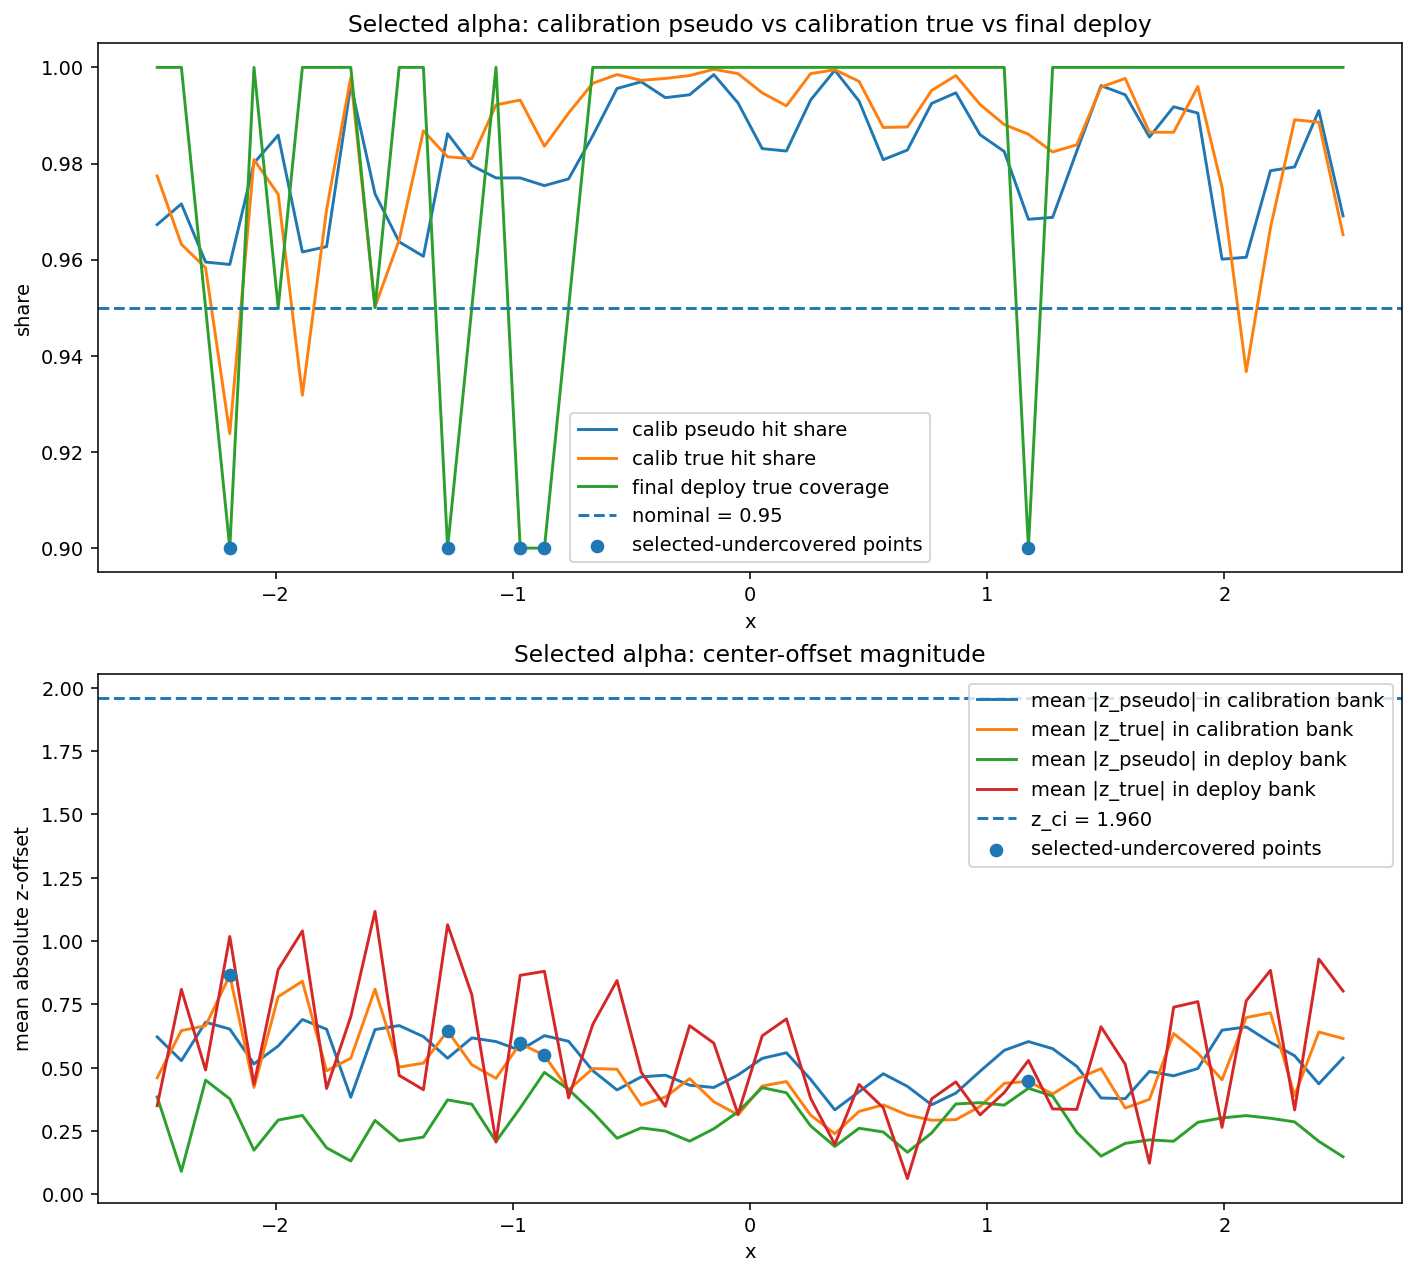

In [9]:

fig, axes = plt.subplots(2, 1, figsize=(10, 9.0), constrained_layout=True)

axes[0].plot(x_ref, selected_center_offset_df["selected_calib_pseudo_hit_share"], label="calib pseudo hit share")
axes[0].plot(x_ref, selected_center_offset_df["selected_calib_true_hit_share"], label="calib true hit share")
axes[0].plot(x_ref, selected_center_offset_df["selected_actual_deploy_coverage"], label="final deploy true coverage")
axes[0].axhline(nominal, linestyle="--", label=f"nominal = {nominal:.2f}")
axes[0].scatter(x_ref[under_idx], selected_center_offset_df.loc[under_mask, "selected_actual_deploy_coverage"], label="selected-undercovered points", zorder=3)
axes[0].set_xlabel("x")
axes[0].set_ylabel("share")
axes[0].set_title("Selected alpha: calibration pseudo vs calibration true vs final deploy")
axes[0].legend()

axes[1].plot(x_ref, selected_center_offset_df["mean_abs_selected_calib_pseudo_z"], label="mean |z_pseudo| in calibration bank")
axes[1].plot(x_ref, selected_center_offset_df["mean_abs_selected_calib_true_z"], label="mean |z_true| in calibration bank")
axes[1].plot(x_ref, selected_center_offset_df["mean_abs_selected_deploy_pseudo_z"], label="mean |z_pseudo| in deploy bank")
axes[1].plot(x_ref, selected_center_offset_df["mean_abs_selected_deploy_true_z"], label="mean |z_true| in deploy bank")
axes[1].axhline(z_ci, linestyle="--", label=f"z_ci = {z_ci:.3f}")
axes[1].scatter(x_ref[under_idx], selected_center_offset_df.loc[under_mask, "mean_abs_selected_calib_true_z"], label="selected-undercovered points", zorder=3)
axes[1].set_xlabel("x")
axes[1].set_ylabel("mean absolute z-offset")
axes[1].set_title("Selected alpha: center-offset magnitude")
axes[1].legend()

plt.savefig(OUTPUT_DIR / "02_selected_center_offset_audit.png", bbox_inches="tight")
plt.show()


## 6. Direction-level diagnostics


The repeated symmetric cross-fit pilot introduces an extra layer of randomness: **direction-level surfaces**.
This section measures how much heterogeneity remains across directions after averaging over bootstrap within each direction.


In [10]:

directional_summary_df = pd.DataFrame({
    "x": x_ref,
    "true_f": true_f_ref,
    "mean_selected_directional_est_sd": selected_directional_est_sd_mat.mean(axis=0),
    "mean_selected_directional_calib_true_sd": selected_directional_true_sd_mat.mean(axis=0),
    "selected_deploy_minus_estimated": pointwise_selected_df["selected_deploy_minus_estimated"],
    "selected_deploy_minus_calib_true": pointwise_selected_df["selected_deploy_minus_calib_true"],
    "selected_actual_deploy_coverage": pointwise_selected_actual,
})
directional_summary_df.to_csv(OUTPUT_DIR / "08_directional_instability_summary.csv", index=False)

directional_under_df = directional_summary_df.loc[under_mask].copy().sort_values(["selected_actual_deploy_coverage", "x"]).reset_index(drop=True)
directional_under_df.to_csv(OUTPUT_DIR / "09_undercovered_directional_instability_summary.csv", index=False)
directional_under_df


,x,true_f,mean_selected_directional_est_sd,mean_selected_directional_calib_true_sd,selected_deploy_minus_estimated,selected_deploy_minus_calib_true,selected_actual_deploy_coverage
0,-2.193878,-0.460571,0.053850,0.057447,-0.0590,-0.0238,0.9
1,-1.275510,-1.374411,0.028179,0.020663,-0.0862,-0.0814,0.9
2,-0.969388,-0.295281,0.040268,0.011027,-0.0770,-0.0932,0.9
3,-0.867347,0.311308,0.046240,0.019812,-0.0754,-0.0836,0.9
4,1.173469,0.422048,0.045728,0.018914,-0.0684,-0.0861,0.9


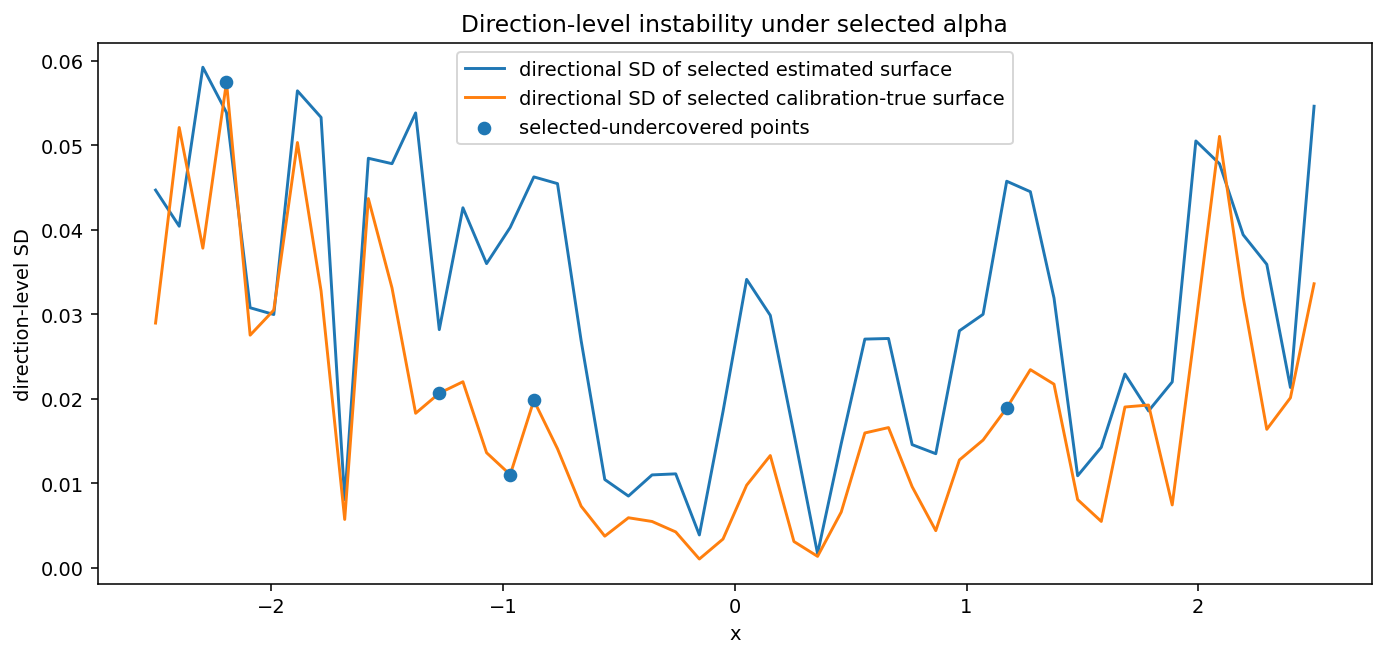

In [11]:

plt.figure(figsize=(10, 4.8))
plt.plot(x_ref, directional_summary_df["mean_selected_directional_est_sd"], label="directional SD of selected estimated surface")
plt.plot(x_ref, directional_summary_df["mean_selected_directional_calib_true_sd"], label="directional SD of selected calibration-true surface")
if U > 0:
    plt.scatter(x_ref[under_idx], directional_summary_df.loc[under_mask, "mean_selected_directional_calib_true_sd"], label="selected-undercovered points", zorder=3)
plt.xlabel("x")
plt.ylabel("direction-level SD")
plt.title("Direction-level instability under selected alpha")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "09_directional_instability_plot.png", bbox_inches="tight")
plt.show()


## 7. All-alpha diagnostics on the selected-undercovered points


For the points that remain undercovered under the selected final deployed rule, inspect all alpha values for:

- estimated pseudo coverage
- calibration-bank true coverage
- final deployed true coverage
- pseudo-target bias
- deploy transfer gap
- total gap
- direction-level SD of estimated coverage
- direction-level SD of calibration true coverage


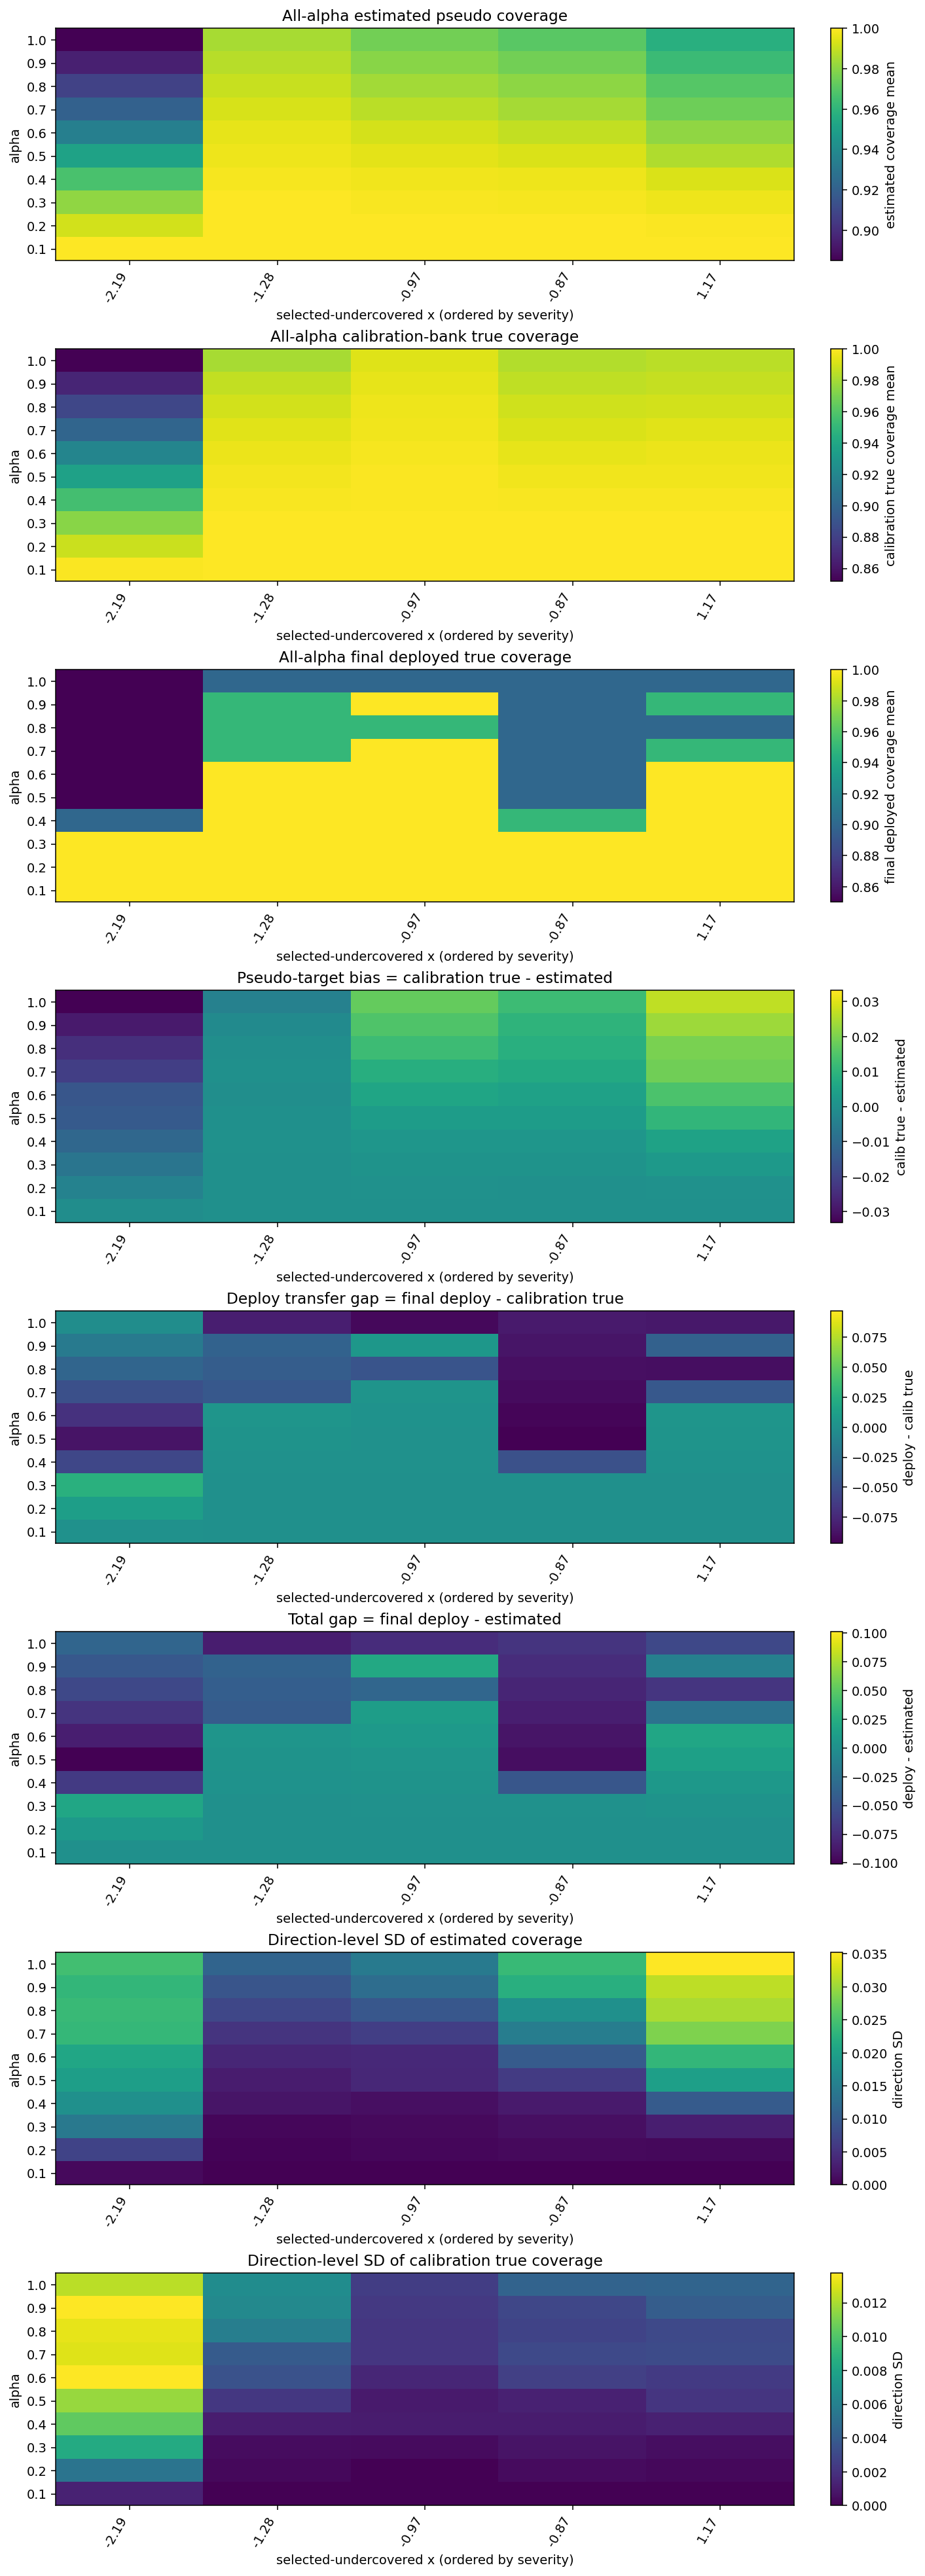

In [12]:

if U > 0:
    severity_order = np.argsort(pointwise_selected_actual[under_idx])
    under_idx_ord = under_idx[severity_order]
    under_x_ord = x_ref[under_idx_ord]

    est_under = est_cov_all_mean[under_idx_ord, :]
    calib_true_under = calib_true_cov_all_mean[under_idx_ord, :]
    deploy_under = actual_cov_all_mean[under_idx_ord, :]
    pseudo_bias_under = calib_true_under - est_under
    deploy_transfer_under = deploy_under - calib_true_under
    total_gap_under = deploy_under - est_under
    est_dir_sd_under = directional_cov_tensor[:, under_idx_ord, :, :].mean(axis=0).std(axis=2, ddof=1)
    calib_true_dir_sd_under = calib_true_cov_dir_tensor[:, under_idx_ord, :, :].mean(axis=0).std(axis=2, ddof=1)

    fig, axes = plt.subplots(8, 1, figsize=(max(10, 0.6 * U), 28), constrained_layout=True)
    mats = [
        (est_under, "All-alpha estimated pseudo coverage", "estimated coverage mean", "unsigned"),
        (calib_true_under, "All-alpha calibration-bank true coverage", "calibration true coverage mean", "unsigned"),
        (deploy_under, "All-alpha final deployed true coverage", "final deployed coverage mean", "unsigned"),
        (pseudo_bias_under, "Pseudo-target bias = calibration true - estimated", "calib true - estimated", "signed"),
        (deploy_transfer_under, "Deploy transfer gap = final deploy - calibration true", "deploy - calib true", "signed"),
        (total_gap_under, "Total gap = final deploy - estimated", "deploy - estimated", "signed"),
        (est_dir_sd_under, "Direction-level SD of estimated coverage", "direction SD", "unsigned"),
        (calib_true_dir_sd_under, "Direction-level SD of calibration true coverage", "direction SD", "unsigned"),
    ]

    for ax, (mat, title, cbar_label, kind) in zip(axes, mats):
        if kind == "signed":
            vmax = np.max(np.abs(mat)) if mat.size else 1.0
            im = ax.imshow(mat.T, aspect="auto", origin="lower", vmin=-vmax, vmax=vmax)
        else:
            im = ax.imshow(mat.T, aspect="auto", origin="lower")
        ax.set_title(title)
        ax.set_xlabel("selected-undercovered x (ordered by severity)")
        ax.set_ylabel("alpha")
        ax.set_xticks(np.arange(U))
        ax.set_xticklabels([f"{x:.2f}" for x in under_x_ord], rotation=60, ha="right")
        ax.set_yticks(np.arange(A))
        ax.set_yticklabels([f"{a:.1f}" for a in alpha_vals_ref])
        fig.colorbar(im, ax=ax, label=cbar_label)

    plt.savefig(OUTPUT_DIR / "03_undercovered_all_alpha_eightway_heatmaps.png", bbox_inches="tight")
    plt.show()


## 8. Best-alpha comparisons: estimate vs calibration-true vs deployed-true

In [13]:

compare_rows = []
if U > 0:
    for j in under_idx:
        est_vec = est_cov_all_mean[j, :]
        calib_true_vec = calib_true_cov_all_mean[j, :]
        act_vec = actual_cov_all_mean[j, :]
        best_est_idx = int(np.argmin(np.abs(est_vec - nominal)))
        best_calib_true_idx = int(np.argmin(np.abs(calib_true_vec - nominal)))
        best_act_idx = int(np.argmin(np.abs(act_vec - nominal)))
        compare_rows.append({
            "x": float(x_ref[j]),
            "true_f": float(true_f_ref[j]),
            "selected_actual_deploy_coverage": float(pointwise_selected_actual[j]),
            "selected_estimated_coverage": float(pointwise_selected_df.loc[j, "selected_estimated_coverage"]),
            "selected_calib_true_hit_share": float(pointwise_selected_df.loc[j, "selected_calib_true_hit_share"]),
            "selected_alpha_mean": float(selected_alpha_mat[:, j].mean()),
            "selected_alpha_sd": float(selected_alpha_mat[:, j].std(ddof=1)) if R > 1 else 0.0,
            "best_alpha_by_estimated_mean": float(alpha_vals_ref[best_est_idx]),
            "best_estimated_coverage": float(est_vec[best_est_idx]),
            "best_estimated_abs_error_to_nominal": float(abs(est_vec[best_est_idx] - nominal)),
            "best_alpha_by_calib_true_mean": float(alpha_vals_ref[best_calib_true_idx]),
            "best_calib_true_coverage": float(calib_true_vec[best_calib_true_idx]),
            "best_calib_true_abs_error_to_nominal": float(abs(calib_true_vec[best_calib_true_idx] - nominal)),
            "best_alpha_by_actual_deploy_mean": float(alpha_vals_ref[best_act_idx]),
            "best_actual_deploy_coverage": float(act_vec[best_act_idx]),
            "best_actual_abs_error_to_nominal": float(abs(act_vec[best_act_idx] - nominal)),
            "best_est_vs_calib_true_match": bool(np.isclose(alpha_vals_ref[best_est_idx], alpha_vals_ref[best_calib_true_idx])),
            "best_calib_true_vs_actual_match": bool(np.isclose(alpha_vals_ref[best_calib_true_idx], alpha_vals_ref[best_act_idx])),
            "best_est_vs_actual_match": bool(np.isclose(alpha_vals_ref[best_est_idx], alpha_vals_ref[best_act_idx])),
        })

compare_df = pd.DataFrame(compare_rows)
if U > 0:
    labels = []
    tol = 0.02
    for _, row in compare_df.iterrows():
        if row["best_actual_abs_error_to_nominal"] <= tol:
            if row["best_est_vs_actual_match"]:
                lbl = "actual_support_exists_same_as_est"
            elif row["best_calib_true_vs_actual_match"]:
                lbl = "actual_support_exists_same_as_calib_true"
            else:
                lbl = "actual_support_exists_but_both_selection_stages_miss"
        else:
            lbl = "no_actual_alpha_near_nominal"
        labels.append(lbl)
    compare_df["selection_chain_label"] = labels

compare_df.to_csv(OUTPUT_DIR / "05_undercovered_best_alpha_threeway_compare.csv", index=False)
compare_df


,x,true_f,selected_actual_deploy_coverage,selected_estimated_coverage,selected_calib_true_hit_share,selected_alpha_mean,selected_alpha_sd,best_alpha_by_estimated_mean,best_estimated_coverage,best_estimated_abs_error_to_nominal,best_alpha_by_calib_true_mean,best_calib_true_coverage,best_calib_true_abs_error_to_nominal,best_alpha_by_actual_deploy_mean,best_actual_deploy_coverage,best_actual_abs_error_to_nominal,best_est_vs_calib_true_match,best_calib_true_vs_actual_match,best_est_vs_actual_match,selection_chain_label
0,-2.193878,-0.460571,0.9,0.9590,0.9238,0.580,0.228496,0.5,0.9511,0.0011,0.4,0.9558,0.0058,0.4,0.90,0.05,False,True,False,no_actual_alpha_near_nominal
1,-1.275510,-1.374411,0.9,0.9862,0.9814,0.990,0.044721,1.0,0.9849,0.0349,1.0,0.9808,0.0308,0.7,0.95,0.00,True,False,False,actual_support_exists_but_both_selection_stage...
2,-0.969388,-0.295281,0.9,0.9770,0.9932,0.985,0.048936,1.0,0.9755,0.0255,1.0,0.9929,0.0429,0.8,0.95,0.00,True,False,False,actual_support_exists_but_both_selection_stage...
3,-0.867347,0.311308,0.9,0.9754,0.9836,0.970,0.092338,1.0,0.9707,0.0207,1.0,0.9829,0.0329,0.4,0.95,0.00,True,False,False,actual_support_exists_but_both_selection_stage...
4,1.173469,0.422048,0.9,0.9684,0.9861,0.915,0.172520,1.0,0.9576,0.0076,1.0,0.9845,0.0345,0.7,0.95,0.00,True,False,False,actual_support_exists_but_both_selection_stage...


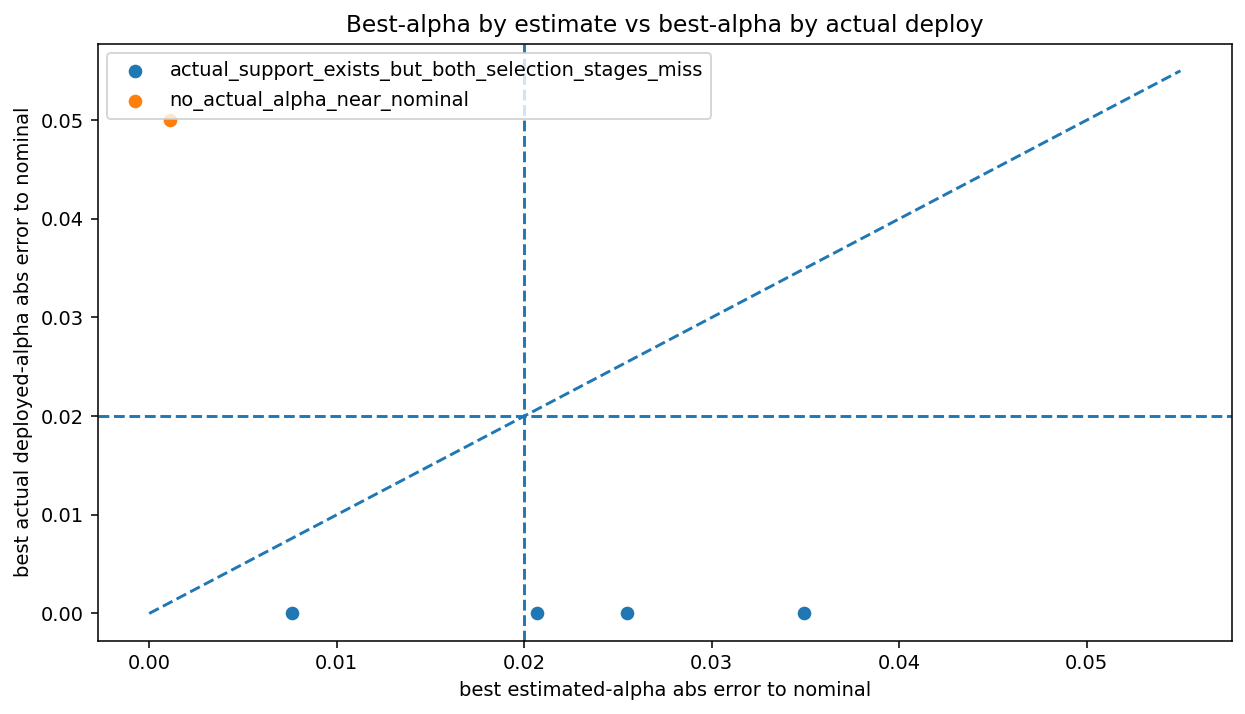

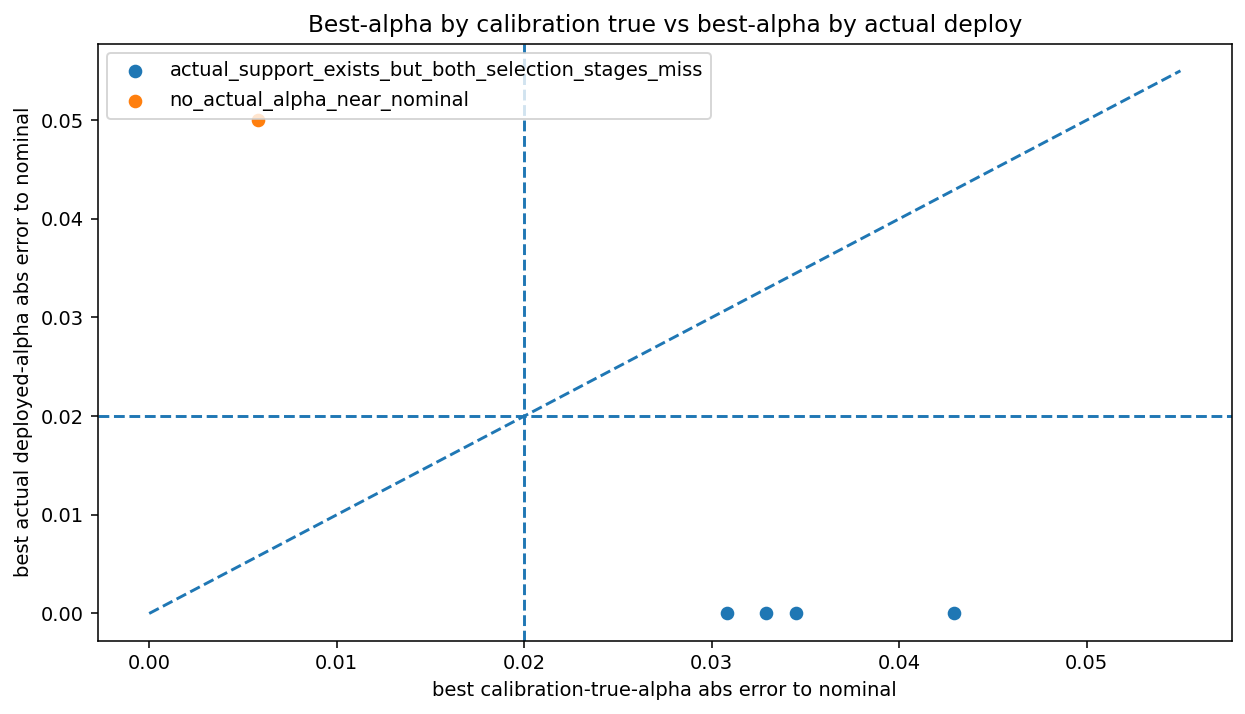

In [14]:

if U > 0:
    plt.figure(figsize=(9, 5.2))
    xvals = compare_df["best_estimated_abs_error_to_nominal"].to_numpy(dtype=float)
    yvals = compare_df["best_actual_abs_error_to_nominal"].to_numpy(dtype=float)
    for lbl in sorted(compare_df["selection_chain_label"].unique()):
        mask = compare_df["selection_chain_label"] == lbl
        plt.scatter(xvals[mask.to_numpy()], yvals[mask.to_numpy()], label=lbl)
    lim_hi = max(xvals.max(initial=0.0), yvals.max(initial=0.0), 0.03) + 0.005
    plt.plot([0.0, lim_hi], [0.0, lim_hi], linestyle="--")
    plt.axhline(0.02, linestyle="--")
    plt.axvline(0.02, linestyle="--")
    plt.xlabel("best estimated-alpha abs error to nominal")
    plt.ylabel("best actual deployed-alpha abs error to nominal")
    plt.title("Best-alpha by estimate vs best-alpha by actual deploy")
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "04_best_alpha_est_vs_actual_scatter.png", bbox_inches="tight")
    plt.show()

    plt.figure(figsize=(9, 5.2))
    xvals = compare_df["best_calib_true_abs_error_to_nominal"].to_numpy(dtype=float)
    yvals = compare_df["best_actual_abs_error_to_nominal"].to_numpy(dtype=float)
    for lbl in sorted(compare_df["selection_chain_label"].unique()):
        mask = compare_df["selection_chain_label"] == lbl
        plt.scatter(xvals[mask.to_numpy()], yvals[mask.to_numpy()], label=lbl)
    lim_hi = max(xvals.max(initial=0.0), yvals.max(initial=0.0), 0.03) + 0.005
    plt.plot([0.0, lim_hi], [0.0, lim_hi], linestyle="--")
    plt.axhline(0.02, linestyle="--")
    plt.axvline(0.02, linestyle="--")
    plt.xlabel("best calibration-true-alpha abs error to nominal")
    plt.ylabel("best actual deployed-alpha abs error to nominal")
    plt.title("Best-alpha by calibration true vs best-alpha by actual deploy")
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "05_best_alpha_calibtrue_vs_actual_scatter.png", bbox_inches="tight")
    plt.show()


## 9. Undercovered-point source decomposition


For each selected-undercovered point, summarize whether the failure is driven more by:

- **pseudo-target bias**
- **deploy transfer gap**
- or a mixed contribution


In [15]:

decomp_rows = []
if U > 0:
    for j in under_idx:
        est_vec = est_cov_all_mean[j, :]
        calib_true_vec = calib_true_cov_all_mean[j, :]
        deploy_vec = actual_cov_all_mean[j, :]
        pseudo_bias_vec = calib_true_vec - est_vec
        transfer_vec = deploy_vec - calib_true_vec
        total_gap_vec = deploy_vec - est_vec
        mean_abs_pseudo_bias = float(np.mean(np.abs(pseudo_bias_vec)))
        mean_abs_transfer = float(np.mean(np.abs(transfer_vec)))
        mean_abs_total = float(np.mean(np.abs(total_gap_vec)))
        if mean_abs_pseudo_bias > 1.25 * mean_abs_transfer:
            driver = "pseudo_target_bias_priority"
        elif mean_abs_transfer > 1.25 * mean_abs_pseudo_bias:
            driver = "deploy_transfer_priority"
        else:
            driver = "mixed"
        decomp_rows.append({
            "x": float(x_ref[j]),
            "selected_actual_deploy_coverage": float(pointwise_selected_actual[j]),
            "selected_estimated_coverage": float(pointwise_selected_df.loc[j, "selected_estimated_coverage"]),
            "selected_calib_true_hit_share": float(pointwise_selected_df.loc[j, "selected_calib_true_hit_share"]),
            "selected_calib_true_minus_estimated": float(pointwise_selected_df.loc[j, "selected_calib_true_minus_estimated"]),
            "selected_deploy_minus_calib_true": float(pointwise_selected_df.loc[j, "selected_deploy_minus_calib_true"]),
            "selected_deploy_minus_estimated": float(pointwise_selected_df.loc[j, "selected_deploy_minus_estimated"]),
            "mean_abs_pseudo_bias_over_all_alpha": mean_abs_pseudo_bias,
            "mean_abs_deploy_transfer_over_all_alpha": mean_abs_transfer,
            "mean_abs_total_gap_over_all_alpha": mean_abs_total,
            "dominant_driver": driver,
        })

decomp_df = pd.DataFrame(decomp_rows).sort_values(["selected_actual_deploy_coverage", "x"], ascending=[True, True])
decomp_df.to_csv(OUTPUT_DIR / "06_undercovered_driver_decomposition.csv", index=False)
decomp_df


,x,selected_actual_deploy_coverage,selected_estimated_coverage,selected_calib_true_hit_share,selected_calib_true_minus_estimated,selected_deploy_minus_calib_true,selected_deploy_minus_estimated,mean_abs_pseudo_bias_over_all_alpha,mean_abs_deploy_transfer_over_all_alpha,mean_abs_total_gap_over_all_alpha,dominant_driver
0,-2.193878,0.9,0.9590,0.9238,-0.0352,-0.0238,-0.0590,0.01592,0.03523,0.04879,deploy_transfer_priority
1,-1.275510,0.9,0.9862,0.9814,-0.0048,-0.0814,-0.0862,0.00068,0.02092,0.02152,deploy_transfer_priority
2,-0.969388,0.9,0.9770,0.9932,0.0162,-0.0932,-0.0770,0.00656,0.01520,0.01582,deploy_transfer_priority
3,-0.867347,0.9,0.9754,0.9836,0.0082,-0.0836,-0.0754,0.00493,0.05898,0.05429,deploy_transfer_priority
4,1.173469,0.9,0.9684,0.9861,0.0177,-0.0861,-0.0684,0.01220,0.02645,0.02083,deploy_transfer_priority


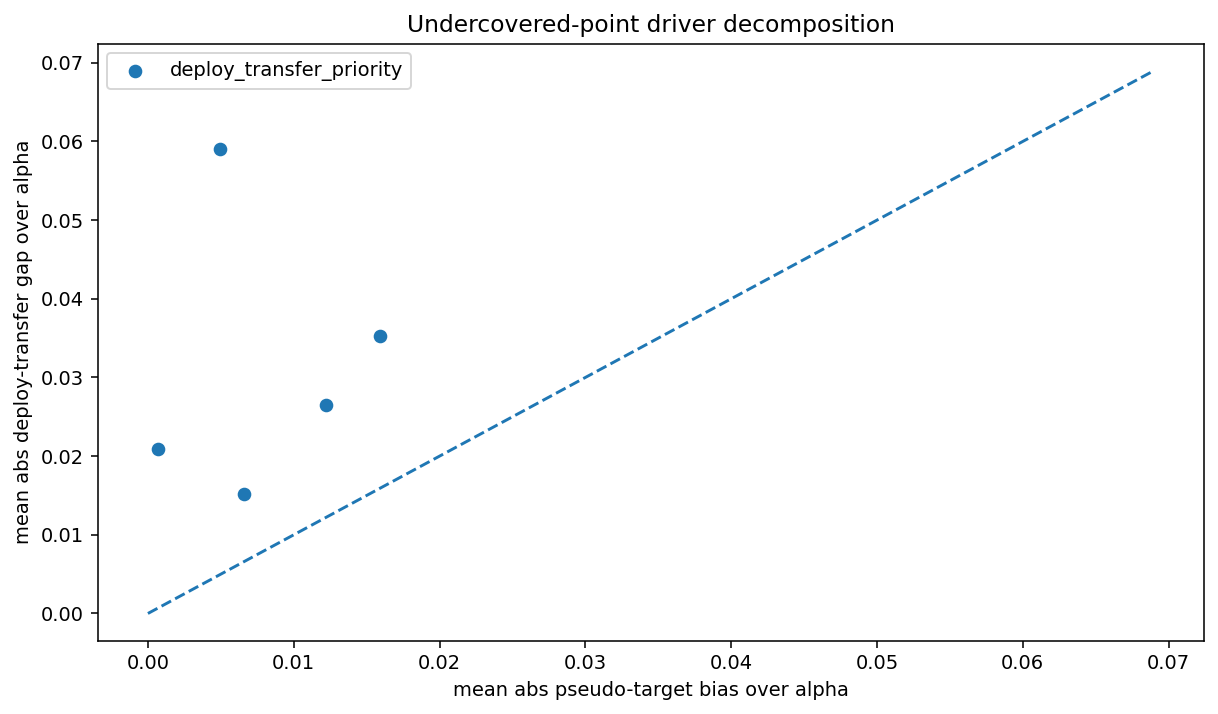

In [16]:

if U > 0:
    plt.figure(figsize=(8.8, 5.2))
    xvals = decomp_df["mean_abs_pseudo_bias_over_all_alpha"].to_numpy(dtype=float)
    yvals = decomp_df["mean_abs_deploy_transfer_over_all_alpha"].to_numpy(dtype=float)
    for lbl in sorted(decomp_df["dominant_driver"].unique()):
        mask = decomp_df["dominant_driver"] == lbl
        plt.scatter(xvals[mask.to_numpy()], yvals[mask.to_numpy()], label=lbl)
    lim_hi = max(xvals.max(initial=0.0), yvals.max(initial=0.0)) + 0.01
    plt.plot([0.0, lim_hi], [0.0, lim_hi], linestyle="--")
    plt.xlabel("mean abs pseudo-target bias over alpha")
    plt.ylabel("mean abs deploy-transfer gap over alpha")
    plt.title("Undercovered-point driver decomposition")
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "06_driver_decomposition_scatter.png", bbox_inches="tight")
    plt.show()


## 10. Long-format helper table for filtering outside the notebook

In [17]:

long_rows = []
if U > 0:
    for j in under_idx:
        for ai, alpha in enumerate(alpha_vals_ref):
            pseudo_z_here = calib_pseudo_z_tensor[:, j, ai, :, :].reshape(-1)
            true_z_here = calib_true_z_tensor[:, j, ai, :, :].reshape(-1)
            dir_est_here = directional_cov_tensor[:, j, ai, :].reshape(-1)
            dir_true_here = calib_true_cov_dir_tensor[:, j, ai, :].reshape(-1)
            calib_true_hit_boot_here = ((true_f_ref[j] >= np.stack([r["calib_lower"][:, ai, :, j] for r in records])) & (true_f_ref[j] <= np.stack([r["calib_upper"][:, ai, :, j] for r in records]))).reshape(-1)
            long_rows.append({
                "x": float(x_ref[j]),
                "true_f": float(true_f_ref[j]),
                "alpha": float(alpha),
                "selected_actual_deploy_coverage": float(pointwise_selected_actual[j]),
                "selected_estimated_coverage": float(pointwise_selected_df.loc[j, "selected_estimated_coverage"]),
                "estimated_coverage_mean": float(est_cov_all_mean[j, ai]),
                "calibration_pseudo_hit_mean": float(calib_pseudo_cov_all_mean[j, ai]),
                "calibration_true_hit_mean": float(calib_true_cov_all_mean[j, ai]),
                "final_deployed_coverage_mean": float(actual_cov_all_mean[j, ai]),
                "pseudo_target_bias": float(calib_true_cov_all_mean[j, ai] - est_cov_all_mean[j, ai]),
                "deploy_transfer_gap": float(actual_cov_all_mean[j, ai] - calib_true_cov_all_mean[j, ai]),
                "total_gap": float(actual_cov_all_mean[j, ai] - est_cov_all_mean[j, ai]),
                "mean_abs_calib_pseudo_z": float(np.mean(np.abs(pseudo_z_here))),
                "mean_abs_calib_true_z": float(np.mean(np.abs(true_z_here))),
                "mean_abs_calib_true_minus_pseudo_z": float(np.mean(np.abs(true_z_here)) - np.mean(np.abs(pseudo_z_here))),
                "direction_estimated_sd": float(np.std(dir_est_here, ddof=1)) if dir_est_here.size > 1 else 0.0,
                "direction_calib_true_sd": float(np.std(dir_true_here, ddof=1)) if dir_true_here.size > 1 else 0.0,
                "calib_true_hit_boot_sd": float(np.std(calib_true_hit_boot_here, ddof=1)) if calib_true_hit_boot_here.size > 1 else 0.0,
                "estimated_abs_error_to_nominal": float(abs(est_cov_all_mean[j, ai] - nominal)),
                "calib_true_abs_error_to_nominal": float(abs(calib_true_cov_all_mean[j, ai] - nominal)),
                "deploy_abs_error_to_nominal": float(abs(actual_cov_all_mean[j, ai] - nominal)),
            })
undercovered_long_df = pd.DataFrame(long_rows)
undercovered_long_df.to_csv(OUTPUT_DIR / "07_undercovered_all_alpha_long.csv", index=False)
undercovered_long_df.head() if U > 0 else None


,x,true_f,alpha,selected_actual_deploy_coverage,selected_estimated_coverage,estimated_coverage_mean,calibration_pseudo_hit_mean,calibration_true_hit_mean,final_deployed_coverage_mean,pseudo_target_bias,...,total_gap,mean_abs_calib_pseudo_z,mean_abs_calib_true_z,mean_abs_calib_true_minus_pseudo_z,direction_estimated_sd,direction_calib_true_sd,calib_true_hit_boot_sd,estimated_abs_error_to_nominal,calib_true_abs_error_to_nominal,deploy_abs_error_to_nominal
0,-2.193878,-0.460571,0.1,0.9,0.959,0.9996,0.9996,0.9990,1.00,-0.0006,...,0.0004,0.304485,0.393955,0.089469,0.002807,0.004808,0.031609,0.0496,0.0490,0.05
1,-2.193878,-0.460571,0.2,0.9,0.959,0.9922,0.9922,0.9884,1.00,-0.0038,...,0.0078,0.419070,0.541572,0.122502,0.033717,0.020968,0.107082,0.0422,0.0384,0.05
2,-2.193878,-0.460571,0.3,0.9,0.959,0.9811,0.9811,0.9737,1.00,-0.0074,...,0.0189,0.505742,0.653230,0.147489,0.058737,0.033883,0.160034,0.0311,0.0237,0.05
3,-2.193878,-0.460571,0.4,0.9,0.959,0.9668,0.9668,0.9558,0.90,-0.0110,...,-0.0668,0.578196,0.746578,0.168383,0.082558,0.044860,0.205549,0.0168,0.0058,0.05
4,-2.193878,-0.460571,0.5,0.9,0.959,0.9511,0.9511,0.9367,0.85,-0.0144,...,-0.1011,0.641680,0.828277,0.186597,0.102250,0.054975,0.243514,0.0011,0.0133,0.10


## 11. Quick text summary

In [18]:

print("==== CROSSFIT COMPREHENSIVE DIAGNOSTIC SUMMARY ====")
for k, v in {**summary, **recon_summary}.items():
    print(f"{k}: {v}")

print()
print(f"Saved outputs to: {OUTPUT_DIR}")
print("\nMain tables:")
for name in [
    "00_overall_summary.csv",
    "01_pointwise_selected_chain_summary.csv",
    "02_undercovered_selected_chain_summary.csv",
    "03_selected_center_offset_summary.csv",
    "04_undercovered_selected_center_offset_summary.csv",
    "05_undercovered_best_alpha_threeway_compare.csv",
    "06_undercovered_driver_decomposition.csv",
    "07_undercovered_all_alpha_long.csv",
    "08_directional_instability_summary.csv",
    "09_undercovered_directional_instability_summary.csv",
]:
    print(" ", OUTPUT_DIR / name)

if U > 0:
    print(f"\nUndercovered points: {U}")
    worst = undercovered_selected_df.iloc[0]
    print(f"Worst selected-undercovered x = {worst['x']:.6f}")
    print(f" selected estimated coverage    = {worst['selected_estimated_coverage']:.6f}")
    print(f" selected calibration true-hit = {worst['selected_calib_true_hit_share']:.6f}")
    print(f" selected final deployed cover = {worst['selected_actual_deploy_coverage']:.6f}")
    print(f" directional est SD            = {worst['selected_directional_estimated_sd']:.6f}")
    print(f" directional calib true SD     = {worst['selected_directional_calib_true_sd']:.6f}")
    print("\nSelection-chain label counts:")
    print(compare_df["selection_chain_label"].value_counts(dropna=False))
    print("\nDriver label counts:")
    print(decomp_df["dominant_driver"].value_counts(dropna=False))


==== CROSSFIT COMPREHENSIVE DIAGNOSTIC SUMMARY ====
R: 20
J: 50
A: 10
S: 10
B: 50
rep_id_min: 0
rep_id_max: 19
nominal: 0.95
undercovered_selected_points: 5
recon_all_alpha_curve_match: True
recon_all_mu_match: True
recon_all_std_match: True
recon_all_lower_match: True
recon_all_upper_match: True
recon_all_est_match_csv_vs_crossfit: True
recon_all_est_match_crossfit_vs_calib_bank: True
recon_all_hit_match: True

Saved outputs to: C:\Users\yangy\26 spring\with reference\crossfit\comprehensive_diagnostics

Main tables:
  C:\Users\yangy\26 spring\with reference\crossfit\comprehensive_diagnostics\00_overall_summary.csv
  C:\Users\yangy\26 spring\with reference\crossfit\comprehensive_diagnostics\01_pointwise_selected_chain_summary.csv
  C:\Users\yangy\26 spring\with reference\crossfit\comprehensive_diagnostics\02_undercovered_selected_chain_summary.csv
  C:\Users\yangy\26 spring\with reference\crossfit\comprehensive_diagnostics\03_selected_center_offset_summary.csv
  C:\Users\yangy\26 sprin